# 02.6 -- Does the Chart Auto-Encoder's persistent-homology instrument actually work? A Swiss roll sanity check

CLAUDE.md's rule in its own terms: a model that fails on real data has two possible causes --
the data has no structure to find, or the implementation is broken -- and only a manifold
whose answer is known in advance separates the two. Here the *model* (`cae.ChartAutoEncoder`)
is not new -- it has already passed its own Swiss roll check in `02.2_swiss_roll_cae_check.ipynb`
-- but this notebook is the first time `persistence_probe.readout_matrix`, the
persistent-homology agreement criterion ratified in `02.6-SCREENING-RULE-02.md`, is run on the
CAE's trained decoder rather than on known-answer fixtures.

The CAE enters this axis as this phase's **measured negative control** (D-20). It was excluded
from the halted curvature axis's first tier entirely -- a chart-fragmented decoder cannot be
safely differentiated twice -- and its admission FAILED there (`02.5-09`, curvature Spearman
`-0.0604`). Persistence diagrams are built from point coordinates alone, so none of that
applies here: no C2 guard, no chart-routing awareness, no special casing. This notebook reports
what it measures. A poor result is the expected outcome, not a verdict; a good result is not a
promotion -- this phase promotes nothing (D-10), and `02.5-10` owns that decision.

Bars inside this notebook are **absolute**, because the roll's answer is exact (D-07). The PU
side of this phase's screen is comparative instead -- against a matched baseline and a null --
and belongs to a different arm (`notebooks/diagnostics/decoder_substrate_ph_screen_run.py`)
entirely.


## §1. Setup

In [1]:
import sys
import time
from pathlib import Path

# import pu_manifold exactly as the other notebooks do -- relative, never from src/effdim/
NOTEBOOK_DIR = Path.cwd()
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

t_notebook_start = time.time()

import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.stats import spearmanr
from sklearn.datasets import make_swiss_roll

from pu_manifold import analytic_param, cae, persistence_probe

SEED = 0                    # torch / split seed
FIXTURE_SEED = 20260807     # the roll's own generation seed -- fixed across this phase, so
                             # this notebook's numbers are comparable to the diagnostics
                             # runner's seed-0 CAE rows
N_POINTS = 3000
CHART_DIM = 2                # the roll's true intrinsic dimension
EMBED_DIM = 8                 # the CAE's GLOBAL embedding dimension -- per R1 this, not
                              # CHART_DIM, is the CAE's "encoder latent"
N_CHARTS = 8
HIDDEN = [64, 64]

# cfg reused VERBATIM from notebooks/02.2_swiss_roll_cae_check.ipynb, with ONE field updated
# per the phase's own CURRENT authoritative source: notebooks/diagnostics/
# decoder_substrate_ph_screen_run.py's CFG_CAE, read directly rather than copied from plan
# text or older summaries. That module's own history records why max_epochs moved from 300
# to 800 (topoae alone was still hitting a 300-epoch ceiling on 3/4 seeds under 300); lr=1e-3
# and early_stop_patience=25 were already correct there and are unchanged here. Every fit
# below should end early_stopped=True; if one instead hits the ceiling, that is reported, not
# accepted.
cfg = {
    "seed": SEED, "lr": 1e-3, "weight_decay": 1e-4, "batch": 64,
    "max_epochs": 800, "early_stop_patience": 25, "early_stop_min_delta": 1e-4,
    "n_charts": N_CHARTS, "fps_pretrain_epochs": 20,
    "lip_weight": 1e-3, "lip_every_n_steps": 1,
}

PRESCALE = True    # ratified Q1: symmetric per-cloud pre-scaling via topoae.latent_unit_scale
VIEW = dict(elev=12, azim=-78)  # looks along the roll's extrusion axis, so the spiral shows

# persim.wasserstein's exact matching over sealed persistence_probe.py's H0 diagrams is
# O(n^3) in the number of finite pairs (measured in 02.6-12: ~30s at n=599, ~2s at n=200).
# This notebook needs THREE labelled 16-cell blocks (CAE, matched plain-AE baseline, chance
# null) -- one more than the plain-AE PH notebook's two -- so Sec. 6's persistence read-out
# is computed on a smaller, fixed subsample of the held-out rows: the same row-count-
# reduction pattern 02.6-12-SUMMARY.md records as established (never by editing the sealed
# module, never by shrinking the holdout used everywhere else in this notebook). This row
# count is NOT directly comparable to the diagnostics runner's own 600-row holdout -- only
# internally, across the three blocks below, at this notebook's own row count.
PH_N_HOLDOUT = 150

print(f"torch {torch.__version__}  numpy {np.__version__}")
print(f"cae module: {cae.__file__}")
print(f"persistence_probe module: {persistence_probe.__file__}")
print(f"CAE encoder latent dimension (R1: the global embedding, model.encode(x)) = {EMBED_DIM}")
print(
    f"  -- this is EMBED_DIM, NOT CHART_DIM ({CHART_DIM}); the other two PH candidates' "
    "latents are 2-dimensional, so this asymmetry is printed rather than inferred."
)
print(
    "Reproducibility note: ripser and persim are not declared in pyproject.toml -- CLAUDE.md "
    "bars editing it for the whole v1.1 milestone -- so they must already be installed into "
    "this repository's venv by hand. Presence is confirmed here by the import above "
    "succeeding, never by shelling out to a package manager."
)


torch 2.13.0+cpu  numpy 2.5.1
cae module: /home/akagi/Documents/Projects/EffDim/notebooks/pu_manifold/cae.py
persistence_probe module: /home/akagi/Documents/Projects/EffDim/notebooks/pu_manifold/persistence_probe.py
CAE encoder latent dimension (R1: the global embedding, model.encode(x)) = 8
  -- this is EMBED_DIM, NOT CHART_DIM (2); the other two PH candidates' latents are 2-dimensional, so this asymmetry is printed rather than inferred.
Reproducibility note: ripser and persim are not declared in pyproject.toml -- CLAUDE.md bars editing it for the whole v1.1 milestone -- so they must already be installed into this repository's venv by hand. Presence is confirmed here by the import above succeeding, never by shelling out to a package manager.


## §2. The roll and its two references

X (3000, 3)  train 2400  holdout 600


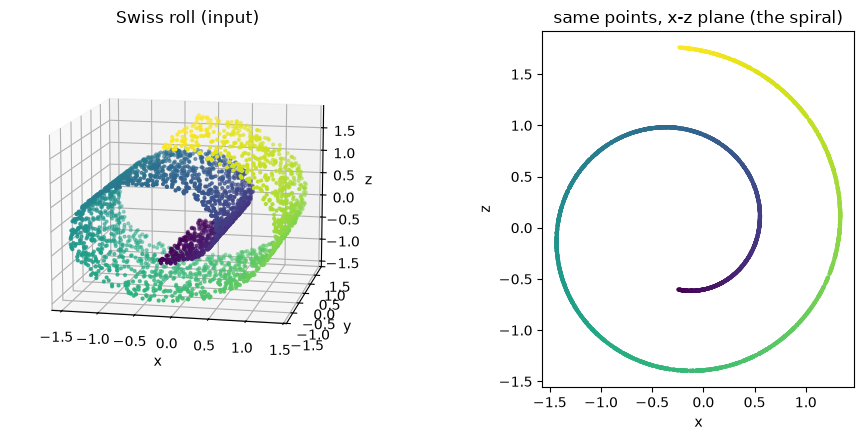


Reference provenance (this notebook's own held-out subsample, n_holdout=600, prescale=False -- matches 02.6-SCREENING-RULE-02.md's own illustrative recipe):


  intrinsic H0: n_features=599  top_life=0.3748  own_diameter=11.3425  ref_max_persistence(denominator)=0.3748  applied_scale=1.0000
  intrinsic H1: n_features=148  top_life=0.4001  own_diameter=11.3425  ref_max_persistence(denominator)=0.4001  applied_scale=1.0000


  ambient H0: n_features=599  top_life=0.3743  own_diameter=4.0417  ref_max_persistence(denominator)=0.3743  applied_scale=1.0000
  ambient H1: n_features=258  top_life=0.7263  own_diameter=4.0417  ref_max_persistence(denominator)=0.7263  applied_scale=1.0000


  between-references H1 bottleneck: 0.36313  ambient-reference own saturation value: 0.36313  saturated=True
  Citing the 'Bottleneck saturation' travelling caveat by name (02.6-SCREENING-RULE-02.md): the (H1, ambient) bottleneck cell below is expected to sit at this same saturation value for any candidate whose latent has correctly unrolled the roll -- a saturated cell is reported with its flag and is never read as a measurement, not before, and not after, any model number appears.


In [2]:
X_raw, t = make_swiss_roll(n_samples=N_POINTS, noise=0.0, random_state=FIXTURE_SEED)
global_std = float(X_raw.std())
X = (X_raw - X_raw.mean(axis=0)) / global_std  # one global scalar -- shape preserved

rng = np.random.default_rng(SEED)
perm = rng.permutation(N_POINTS)
n_train = int(0.8 * N_POINTS)
train_idx, holdout_idx = perm[:n_train], perm[n_train:]

x_all = torch.tensor(X, dtype=torch.float32)
x_train = x_all[train_idx]
x_holdout = x_all[holdout_idx]
t_holdout = t[holdout_idx]

print(f"X {X.shape}  train {len(train_idx)}  holdout {len(holdout_idx)}")

# D-03's two references, built on the SAME held-out row indices as the model's own latent
# and decoder image below (T-02.6R-17 -- mismatched references would compare different
# subsets of the manifold).
intrinsic_ref_holdout = analytic_param.swiss_roll_intrinsic_plane(
    t_holdout, X[holdout_idx, 1], global_std
)
ambient_ref_holdout = X[holdout_idx]

fig = plt.figure(figsize=(10, 4.5))
ax = fig.add_subplot(1, 2, 1, projection="3d")
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=t, cmap="viridis", s=4)
ax.view_init(**VIEW)
ax.set_title("Swiss roll (input)")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")

ax2 = fig.add_subplot(1, 2, 2)
ax2.scatter(X[:, 0], X[:, 2], c=t, cmap="viridis", s=4)
ax2.set_title("same points, x-z plane (the spiral)")
ax2.set_xlabel("x"); ax2.set_ylabel("z"); ax2.set_aspect("equal")
plt.tight_layout()
plt.show()

# Reference provenance -- printed BEFORE any model number, per the two travelling caveats
# (02.6-SCREENING-RULE-02.md). prescale=False here: this is the illustrative, no-pre-scaling
# recipe the ratification document itself uses to state the caveats' figures.
print()
print("Reference provenance (this notebook's own held-out subsample, n_holdout="
      f"{len(holdout_idx)}, prescale=False -- matches 02.6-SCREENING-RULE-02.md's own "
      "illustrative recipe):")
ref_diagrams = {}
for name, cloud in (("intrinsic", intrinsic_ref_holdout), ("ambient", ambient_ref_holdout)):
    D, scale = persistence_probe.cloud_distance_matrix(cloud, prescale=False)
    dgms = persistence_probe.persistence_diagram(D)
    ref_diagrams[name] = dgms
    diameter = float(D.max())
    for k, degree in enumerate(("H0", "H1")):
        dgm = dgms[k]
        top_life = persistence_probe.max_persistence(dgm)
        print(
            f"  {name} {degree}: n_features={dgm.shape[0]}  top_life={top_life:.4f}  "
            f"own_diameter={diameter:.4f}  ref_max_persistence(denominator)={top_life:.4f}  "
            f"applied_scale={scale:.4f}"
        )

h1_agreement = persistence_probe.ph_agreement(ref_diagrams["intrinsic"][1], ref_diagrams["ambient"][1])
ambient_h1_saturation = persistence_probe.saturation_value(ref_diagrams["ambient"][1])
print(
    f"  between-references H1 bottleneck: {h1_agreement['bottleneck']:.5f}  "
    f"ambient-reference own saturation value: {ambient_h1_saturation:.5f}  "
    f"saturated={h1_agreement['saturated']}"
)
print(
    "  Citing the 'Bottleneck saturation' travelling caveat by name "
    "(02.6-SCREENING-RULE-02.md): the (H1, ambient) bottleneck cell below is expected to sit "
    "at this same saturation value for any candidate whose latent has correctly unrolled the "
    "roll -- a saturated cell is reported with its flag and is never read as a measurement, "
    "not before, and not after, any model number appears."
)


## §3. Fit the Chart Auto-Encoder

epochs_run    = 47
wallclock_s   = 47.2
early_stopped = True


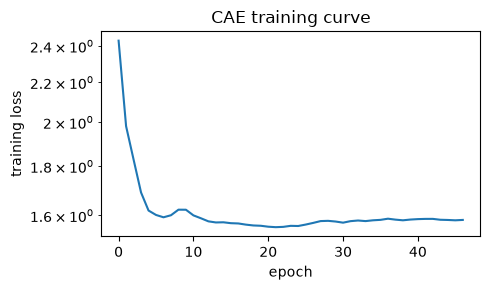


charts surviving = 8 / 8
No C2 guard is applied anywhere in this notebook (T-02.6R-23): persistence diagrams are built from point coordinates alone and need no smoothness assumption, so the chart fragmentation that excluded the CAE from the halted curvature axis's first tier is not an obstruction on this axis (D-22).


In [3]:
torch.manual_seed(SEED)
model = cae.ChartAutoEncoder(
    in_dim=3, embed_dim=EMBED_DIM, chart_dim=CHART_DIM,
    n_charts=N_CHARTS, hidden=HIDDEN, activation="silu",
)

fit = cae.train_cae(model, x_train, cfg)
model.eval()

print(f"epochs_run    = {fit['epochs_run']}")
print(f"wallclock_s   = {fit['wallclock_s']:.1f}")
print(f"early_stopped = {fit['early_stopped']}")
if not fit["early_stopped"]:
    print(
        f"  ** hit the max_epochs={cfg['max_epochs']} ceiling instead of early stopping -- "
        "reported here, not accepted as convergence **"
    )

main_history = [h for h in fit["history"] if h["stage"] == "main"]
plt.figure(figsize=(5, 3))
plt.plot([h["epoch"] for h in main_history], [h["total"] for h in main_history])
plt.yscale("log"); plt.xlabel("epoch"); plt.ylabel("training loss"); plt.title("CAE training curve")
plt.tight_layout()
plt.show()

survival = cae.chart_survival(model, prune_tol=1e-2)
print()
print(f"charts surviving = {survival['n_charts_surviving']} / {survival['n_charts_initial']}")
print(
    "No C2 guard is applied anywhere in this notebook (T-02.6R-23): persistence diagrams are "
    "built from point coordinates alone and need no smoothness assumption, so the chart "
    "fragmentation that excluded the CAE from the halted curvature axis's first tier is not "
    "an obstruction on this axis (D-22)."
)


## §4. The reconstruction, side by side

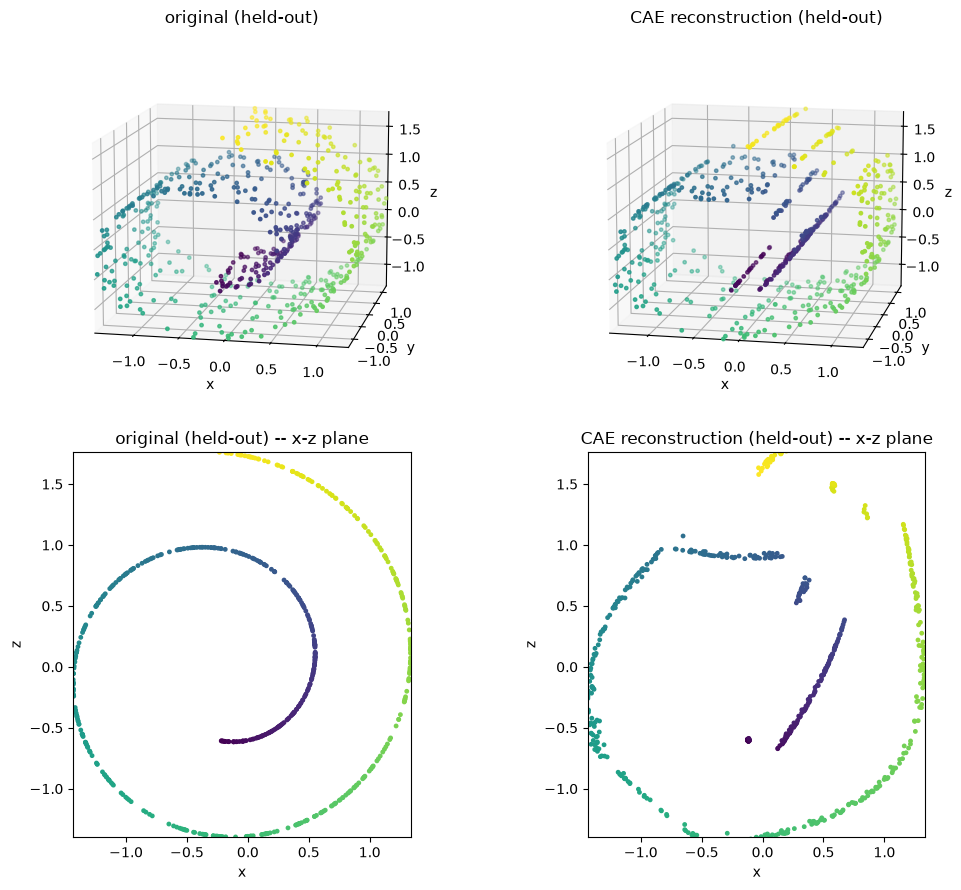

=== held-out reconstruction ===
CAE                        mse_per_dim = 0.002653   rel_err = 0.0521  (5.2%)
matched plain AE (d=2)       mse_per_dim = 0.004951   rel_err = 0.0801  (8.0%)
CAE / matched plain AE mse_per_dim ratio = 1.87x
matched plain AE fit: epochs_run=517  wallclock_s=28.4  early_stopped=True


In [4]:
with torch.no_grad():
    y_holdout = model.reconstruct(x_holdout)  # argmax-chart reconstruction -- the SAME path
                                               # 02.2_swiss_roll_cae_check.ipynb's own SS4/SS5
                                               # cells use. forward() returns z/z_charts/
                                               # y_charts/p/e and NO "y" key -- reading one
                                               # would raise; reading decode_all would
                                               # silently score a per-chart stack instead of
                                               # a reconstruction.

y_holdout_np = y_holdout.numpy()

fig = plt.figure(figsize=(11, 9))
for i, (data, title) in enumerate([(X[holdout_idx], "original (held-out)"), (y_holdout_np, "CAE reconstruction (held-out)")]):
    ax = fig.add_subplot(2, 2, i + 1, projection="3d")
    ax.scatter(data[:, 0], data[:, 1], data[:, 2], c=t_holdout, cmap="viridis", s=6)
    ax.view_init(**VIEW)
    ax.set_title(title)
    ax.set_xlim(X[:, 0].min(), X[:, 0].max())
    ax.set_ylim(X[:, 1].min(), X[:, 1].max())
    ax.set_zlim(X[:, 2].min(), X[:, 2].max())
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")

    ax2 = fig.add_subplot(2, 2, i + 3)
    ax2.scatter(data[:, 0], data[:, 2], c=t_holdout, cmap="viridis", s=6)
    ax2.set_title(f"{title} -- x-z plane")
    ax2.set_xlim(X[:, 0].min(), X[:, 0].max())
    ax2.set_ylim(X[:, 2].min(), X[:, 2].max())
    ax2.set_xlabel("x"); ax2.set_ylabel("z"); ax2.set_aspect("equal")
plt.tight_layout()
plt.show()

cae_stats = cae.reconstruction_stats(x_holdout.double(), y_holdout.double())
rel_err = float(
    (torch.linalg.vector_norm(x_holdout - y_holdout, dim=-1)
     / torch.linalg.vector_norm(x_holdout, dim=-1)).mean()
)

# CLAUDE.md-mandated matched baseline: cae.PlainAutoEncoder at the SAME 2-D bottleneck, same
# width/depth/protocol, exactly as notebooks/02.2_swiss_roll_cae_check.ipynb trains it. Same
# values as `cfg` above, minus the CAE-only fields (n_charts/fps_pretrain_epochs/lip_weight/
# lip_every_n_steps) that cae.train_plain_ae does not read.
plain_cfg = {k: cfg[k] for k in ("seed", "lr", "weight_decay", "batch", "max_epochs", "early_stop_patience", "early_stop_min_delta")}
torch.manual_seed(SEED)
plain = cae.PlainAutoEncoder(3, CHART_DIM, hidden=tuple(HIDDEN), activation="silu")
plain_fit = cae.train_plain_ae(plain, x_train, plain_cfg)
plain.eval()
with torch.no_grad():
    y_plain_holdout = plain(x_holdout)["y"]
plain_stats = cae.reconstruction_stats(x_holdout.double(), y_plain_holdout.double())
plain_rel_err = float(
    (torch.linalg.vector_norm(x_holdout - y_plain_holdout, dim=-1)
     / torch.linalg.vector_norm(x_holdout, dim=-1)).mean()
)

print("=== held-out reconstruction ===")
print(f"CAE                        mse_per_dim = {cae_stats['mse_per_dim']:.6f}   rel_err = {rel_err:.4f}  ({100 * rel_err:.1f}%)")
print(f"matched plain AE (d={CHART_DIM})       mse_per_dim = {plain_stats['mse_per_dim']:.6f}   rel_err = {plain_rel_err:.4f}  ({100 * plain_rel_err:.1f}%)")
print(f"CAE / matched plain AE mse_per_dim ratio = {plain_stats['mse_per_dim'] / cae_stats['mse_per_dim']:.2f}x")
print(f"matched plain AE fit: epochs_run={plain_fit['epochs_run']}  wallclock_s={plain_fit['wallclock_s']:.1f}  early_stopped={plain_fit['early_stopped']}")


## §5. The latent -- an 8-D embedding, projected

CAE latent (model.encode) shape = (600, 8)  -- dimension = 8 (EMBED_DIM), not CHART_DIM = 2


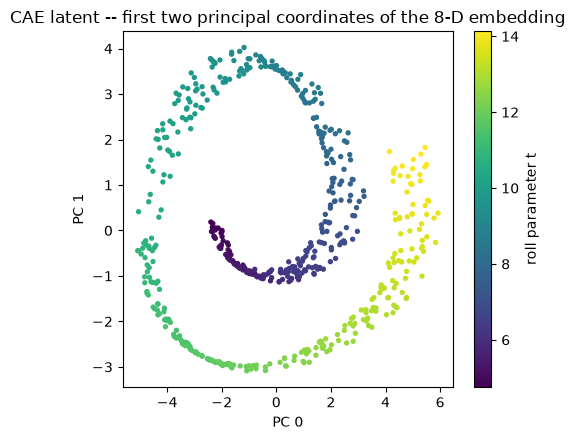

This is a 2-D PROJECTION of a 8-dimensional latent, not the latent itself -- it is suggestive, and Sec. 6's persistence numbers below are the measurement.
Spearman(CAE latent PC1, t) = 0.2283  (p=1.56e-08)  |Spearman| = 0.2283
FOR CONTRAST -- matched plain AE's GENUINE 2-D latent (no projection needed): Spearman(PC1, t) = -0.0174  (p=6.71e-01)  |Spearman| = 0.0174


In [5]:
with torch.no_grad():
    z_holdout = model.encode(x_holdout)  # GLOBAL embedding (R1) -- NOT chart-local
                                          # coordinates; this is the CAE's "encoder latent"
                                          # per the ratified disposition of option group R.
z_holdout_np = z_holdout.double().numpy()
print(f"CAE latent (model.encode) shape = {z_holdout_np.shape}  -- dimension = {EMBED_DIM} (EMBED_DIM), not CHART_DIM = {CHART_DIM}")

z_centered = z_holdout_np - z_holdout_np.mean(axis=0, keepdims=True)
_, _, Vt = np.linalg.svd(z_centered, full_matrices=False)
latent_pc1 = z_centered @ Vt[0]
latent_pc2 = z_centered @ Vt[1]

plt.figure(figsize=(5, 4.5))
sc = plt.scatter(latent_pc1, latent_pc2, c=t_holdout, cmap="viridis", s=8)
plt.colorbar(sc, label="roll parameter t")
plt.title(f"CAE latent -- first two principal coordinates of the {EMBED_DIM}-D embedding")
plt.xlabel("PC 0"); plt.ylabel("PC 1")
plt.tight_layout()
plt.show()
print(
    f"This is a 2-D PROJECTION of a {EMBED_DIM}-dimensional latent, not the latent itself -- "
    "it is suggestive, and Sec. 6's persistence numbers below are the measurement."
)

spearman_r, spearman_p = spearmanr(latent_pc1, t_holdout)
print(f"Spearman(CAE latent PC1, t) = {spearman_r:.4f}  (p={spearman_p:.2e})  |Spearman| = {abs(spearman_r):.4f}")

# For contrast, clearly labelled as such: the matched plain AE's GENUINE 2-D latent, which
# needs no projection.
with torch.no_grad():
    z_plain_holdout = plain.encode(x_holdout).double().numpy()
zc_plain = z_plain_holdout - z_plain_holdout.mean(axis=0, keepdims=True)
_, _, Vt_plain = np.linalg.svd(zc_plain, full_matrices=False)
plain_pc1 = zc_plain @ Vt_plain[0]
plain_spearman_r, plain_spearman_p = spearmanr(plain_pc1, t_holdout)
print(
    f"FOR CONTRAST -- matched plain AE's GENUINE {CHART_DIM}-D latent (no projection needed): "
    f"Spearman(PC1, t) = {plain_spearman_r:.4f}  (p={plain_spearman_p:.2e})  "
    f"|Spearman| = {abs(plain_spearman_r):.4f}"
)


## §6. Persistence agreement, this seed

In [6]:
decoder_image_holdout = y_holdout_np.astype(np.float64)
plain_decoder_image_holdout = y_plain_holdout.double().numpy()

# Fixed subsample of the held-out rows for the persistence computation only (see the
# PH_N_HOLDOUT note in Sec. 1) -- the SAME row subset feeds all clouds below, so
# space-vs-reference comparisons stay index-consistent (T-02.6R-17).
ph_sub = np.random.default_rng(SEED).permutation(len(holdout_idx))[:PH_N_HOLDOUT]
print(f"Persistence read-out computed on a {PH_N_HOLDOUT}-row subsample of the "
      f"{len(holdout_idx)}-row holdout (wall-clock budget; see Sec. 1). This row count "
      "differs from notebooks/diagnostics/decoder_substrate_ph_screen_run.py's own 600-row "
      "holdout, so the numbers below are NOT directly comparable to that runner's 192-number "
      "matrix -- only internally, across the three blocks below, at this notebook's own row "
      "count.")
print()

references_sub = {"intrinsic": intrinsic_ref_holdout[ph_sub], "ambient": ambient_ref_holdout[ph_sub]}


def print_block(label, readout_dict):
    print(f"=== {label} -- all 16 read-out cells (PRESCALE={PRESCALE}) ===")
    for cell in persistence_probe.READOUT_CELLS:
        space, reference, hk, _ = cell.split("|")
        raw_key = cell.replace("_norm", "_raw")
        denom_key = f"{reference}|{hk}|ref_max_persistence"
        sat_key = f"{space}|{reference}|{hk}|saturated"
        print(
            f"  {cell:42s} norm={readout_dict[cell]:9.4f}  raw={readout_dict[raw_key]:9.4f}  "
            f"denom={readout_dict[denom_key]:7.4f}  saturated={readout_dict[sat_key]}"
        )
    for cloud_name in ("latent", "decoder_image", "intrinsic", "ambient"):
        print(f"  {cloud_name}|applied_scale = {readout_dict[f'{cloud_name}|applied_scale']:.4f}")
    print()


# Block 1: the CAE -- latent is the global 8-D embedding (R1), decoder_image is the
# argmax-chart reconstruction (model.reconstruct, never a "y" key).
cae_spaces = {"latent": z_holdout_np[ph_sub], "decoder_image": decoder_image_holdout[ph_sub]}
cae_readout = persistence_probe.readout_matrix(cae_spaces, references_sub, PRESCALE)
print_block(f"CAE, seed={SEED}, latent_dim={EMBED_DIM}", cae_readout)

# Block 2: the matched plain-AE baseline -- genuine 2-D latent, its own decoder image.
plain_spaces = {"latent": z_plain_holdout[ph_sub], "decoder_image": plain_decoder_image_holdout[ph_sub]}
plain_readout = persistence_probe.readout_matrix(plain_spaces, references_sub, PRESCALE)
print_block(f"matched plain AE, seed={SEED}, latent_dim={CHART_DIM}", plain_readout)

# Block 3: the chance null, at the CAE's OWN latent dimension (EMBED_DIM), per this plan's
# explicit instruction -- no decoder exists for a null cloud, so the same null array stands
# in for both the "latent" and "decoder_image" slots readout_matrix requires.
null_rng = np.random.default_rng(SEED + 100)
null_cloud = null_rng.standard_normal((PH_N_HOLDOUT, EMBED_DIM))
null_spaces = {"latent": null_cloud, "decoder_image": null_cloud}
null_readout = persistence_probe.readout_matrix(null_spaces, references_sub, PRESCALE)
print_block(f"chance null, seed={SEED + 100}, latent_dim={EMBED_DIM} (the CAE's own latent dimension)", null_readout)


Persistence read-out computed on a 150-row subsample of the 600-row holdout (wall-clock budget; see Sec. 1). This row count differs from notebooks/diagnostics/decoder_substrate_ph_screen_run.py's own 600-row holdout, so the numbers below are NOT directly comparable to that runner's 192-number matrix -- only internally, across the three blocks below, at this notebook's own row count.



=== CAE, seed=0, latent_dim=8 -- all 16 read-out cells (PRESCALE=True) ===
  latent|intrinsic|H0|bottleneck_norm        norm=   1.8215  raw=   0.6714  denom= 0.3686  saturated=False
  latent|intrinsic|H0|wasserstein_norm       norm= 142.9612  raw=  52.6913  denom= 0.3686  saturated=False
  latent|intrinsic|H1|bottleneck_norm        norm=   3.4491  raw=   0.7051  denom= 0.2044  saturated=False
  latent|intrinsic|H1|wasserstein_norm       norm=  35.8781  raw=   7.3348  denom= 0.2044  saturated=False
  latent|ambient|H0|bottleneck_norm          norm=   0.6118  raw=   0.5625  denom= 0.9193  saturated=False
  latent|ambient|H0|wasserstein_norm         norm=  26.2396  raw=  24.1221  denom= 0.9193  saturated=False
  latent|ambient|H1|bottleneck_norm          norm=   0.8735  raw=   0.7051  denom= 0.8072  saturated=False
  latent|ambient|H1|wasserstein_norm         norm=   8.9504  raw=   7.2252  denom= 0.8072  saturated=False
  decoder_image|intrinsic|H0|bottleneck_norm norm=   1.0718  raw=   0

=== matched plain AE, seed=0, latent_dim=2 -- all 16 read-out cells (PRESCALE=True) ===
  latent|intrinsic|H0|bottleneck_norm        norm=   0.9836  raw=   0.3625  denom= 0.3686  saturated=False
  latent|intrinsic|H0|wasserstein_norm       norm=  19.1113  raw=   7.0439  denom= 0.3686  saturated=False
  latent|intrinsic|H1|bottleneck_norm        norm=   0.4310  raw=   0.0881  denom= 0.2044  saturated=False
  latent|intrinsic|H1|wasserstein_norm       norm=   6.0534  raw=   1.2375  denom= 0.2044  saturated=False
  latent|ambient|H0|bottleneck_norm          norm=   0.3360  raw=   0.3089  denom= 0.9193  saturated=False
  latent|ambient|H0|wasserstein_norm         norm=  28.6300  raw=  26.3197  denom= 0.9193  saturated=False
  latent|ambient|H1|bottleneck_norm          norm=   0.5000  raw=   0.4036  denom= 0.8072  saturated=True
  latent|ambient|H1|wasserstein_norm         norm=   5.6547  raw=   4.5647  denom= 0.8072  saturated=True
  decoder_image|intrinsic|H0|bottleneck_norm norm=   1.057

=== chance null, seed=100, latent_dim=8 (the CAE's own latent dimension) -- all 16 read-out cells (PRESCALE=True) ===
  latent|intrinsic|H0|bottleneck_norm        norm=   4.2579  raw=   1.5693  denom= 0.3686  saturated=False
  latent|intrinsic|H0|wasserstein_norm       norm= 564.4146  raw= 208.0266  denom= 0.3686  saturated=False
  latent|intrinsic|H1|bottleneck_norm        norm=   1.4336  raw=   0.2931  denom= 0.2044  saturated=False
  latent|intrinsic|H1|wasserstein_norm       norm=  83.5349  raw=  17.0777  denom= 0.2044  saturated=False
  latent|ambient|H0|bottleneck_norm          norm=   1.7071  raw=   1.5693  denom= 0.9193  saturated=False
  latent|ambient|H0|wasserstein_norm         norm= 222.0010  raw= 204.0864  denom= 0.9193  saturated=False
  latent|ambient|H1|bottleneck_norm          norm=   0.5000  raw=   0.4036  denom= 0.8072  saturated=True
  latent|ambient|H1|wasserstein_norm         norm=  25.1446  raw=  20.2979  denom= 0.8072  saturated=True
  decoder_image|intrinsic|H0

## §7. Read-out

In [7]:
recon_ok = rel_err < 0.10
charts_ok = survival["n_charts_surviving"] > 1
signature_ok = (
    cae_readout["latent|intrinsic|H1|wasserstein_raw"] < cae_readout["latent|ambient|H1|wasserstein_raw"]
)
beats_null_ok = (
    cae_readout["latent|intrinsic|H0|wasserstein_raw"] < null_readout["latent|intrinsic|H0|wasserstein_raw"]
    and cae_readout["latent|intrinsic|H1|wasserstein_raw"] < null_readout["latent|intrinsic|H1|wasserstein_raw"]
)

print(f"(a) roll reconstructed (held-out rel. err < 0.10)           : {recon_ok}   ({100 * rel_err:.1f}%)")
print(f"(b) more than one chart survived                            : {charts_ok}   ({survival['n_charts_surviving']}/{survival['n_charts_initial']})")
print(
    "(c) D-03 signature holds (H1-to-intrinsic < H1-to-ambient)  : "
    f"{signature_ok}   ({cae_readout['latent|intrinsic|H1|wasserstein_raw']:.4f} vs "
    f"{cae_readout['latent|ambient|H1|wasserstein_raw']:.4f})"
)
print(
    "(d) beats the chance null (H0 and H1 vs intrinsic, both)    : "
    f"{beats_null_ok}   (CAE H0={cae_readout['latent|intrinsic|H0|wasserstein_raw']:.4f} vs "
    f"null H0={null_readout['latent|intrinsic|H0|wasserstein_raw']:.4f}; "
    f"CAE H1={cae_readout['latent|intrinsic|H1|wasserstein_raw']:.4f} vs "
    f"null H1={null_readout['latent|intrinsic|H1|wasserstein_raw']:.4f})"
)

elapsed_s = time.time() - t_notebook_start
print()
print(f"total wall clock: {elapsed_s:.1f}s")
print()

print(
    "This notebook is the measured negative control (D-20), and this read-out is stated in "
    "both directions. A poor result here is the expected outcome and is NOT read as a "
    "verdict: the CAE was excluded from the halted curvature axis's first tier and its "
    "admission FAILED there (02.5-09, curvature Spearman -0.0604). A good result here is "
    "likewise NOT a promotion -- this phase promotes nothing (D-10), and 02.5-10 owns that "
    "decision with every number from this notebook disclosed to it. The standing pattern "
    "this notebook tests against: on PU the CAE preserves H0 merge structure roughly 3.4x "
    "worse than a matched plain autoencoder at the same dimension while reconstructing the "
    "roll about 2.96x better -- and reconstruction quality has already been recorded twice "
    "in this milestone as validating nothing about the geometry (02.6-SCREENING-RULE-02.md, "
    "'inferences that must not be drawn', item 2)."
)


(a) roll reconstructed (held-out rel. err < 0.10)           : True   (5.2%)
(b) more than one chart survived                            : True   (8/8)
(c) D-03 signature holds (H1-to-intrinsic < H1-to-ambient)  : False   (7.3348 vs 7.2252)
(d) beats the chance null (H0 and H1 vs intrinsic, both)    : True   (CAE H0=52.6913 vs null H0=208.0266; CAE H1=7.3348 vs null H1=17.0777)

total wall clock: 97.0s

This notebook is the measured negative control (D-20), and this read-out is stated in both directions. A poor result here is the expected outcome and is NOT read as a verdict: the CAE was excluded from the halted curvature axis's first tier and its admission FAILED there (02.5-09, curvature Spearman -0.0604). A good result here is likewise NOT a promotion -- this phase promotes nothing (D-10), and 02.5-10 owns that decision with every number from this notebook disclosed to it. The standing pattern this notebook tests against: on PU the CAE preserves H0 merge structure roughly 3.4x worse 